
# Домашнє завдання: Інтеграція Python та SQL: запити даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлені необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно інструкції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.


In [1]:
!pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv --quiet

In [2]:
import datetime
import os
import sqlalchemy as sa
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [3]:
def create_connection():
    """
    Створює підключення через SQLAlchemy
    """
    # Завантажуємо змінні середовища
    load_dotenv()

    # Отримуємо параметри з environment variables
    host = os.getenv('DB_HOST', '127.0.0.1')
    port = os.getenv('DB_PORT', '3306')
    user = os.getenv('DB_USER')
    password = os.getenv('DB_PASSWORD')
    database = os.getenv('DB_NAME')

    if not all([user, password, database]):
        raise ValueError("Не всі параметри БД задані в .env файлі!")

    # Створюємо connection string
    connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

    # Створюємо engine з connection pooling
    engine = create_engine(
        connection_string,
        pool_size=2,            # Розмір пулу підключень
        max_overflow=20,        # Максимальна кількість додаткових підключень
        pool_pre_ping=True,     # Перевірка підключення перед використанням
        echo=False              # Логування SQL запитів (True для debug)
    )

    # Тестуємо підключення
    try:
        with engine.connect() as conn:
            result = conn.execute(text("SELECT 1"))
            result.fetchone()

        print("✅ Підключення до БД успішне!")
        print(f"🔗 host={host}, port={port}, db={database}")
        
        return engine

    except Exception as e:
        print(f"❌ Помилка підключення: {e}")
        return None

# Створюємо підключення
engine = create_connection()

✅ Підключення до БД успішне!
🔗 host=127.0.0.1, port=3306, db=classicmodels


### Завдання 1: Простий запит (1 бал)

Ми працюємо з БД Classicmodels.

**Виведіть інформацію про продукти на складі** з наступними полями:
- назва продукту (productName)
- лінійка продукту (productLine)
- кількість на складі (quantityInStock)
- ціна закупки (buyPrice)

Зчитайте дані з БД з допомогою `pd.read_sql()` з SQLAlchemy engine, який ви створили на етапі підготовки.

Виведіть перші 10 продуктів, відсортованих за кількістю на складі (від більшої кількості до меншої).

In [4]:
first_query = """
    SELECT productName, productLine, quantityInStock, buyPrice
    FROM products
    ORDER BY 3 DESC 
    LIMIT 10;
"""

df_products = pd.read_sql(first_query, engine)

print("Продукти на складі:")
display(df_products)

Продукти на складі:


,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96



### Завдання 2: Аналітика замовлень за 2004 рік (3 бали)

**Виведіть детальну інформацію про замовлення за 2004 рік** з наступними полями:
- Номер замовлення (orderNumber)
- Дата замовлення (orderDate)
- Статус замовлення (status)
- Ім'я клієнта (customerName)
- Країна клієнта (country)
- Загальна сума замовлення (сума всіх orderdetails.quantityOrdered * orderdetails.priceEach)

Використайте JOIN для об'єднання таблиць orders, customers, orderdetails. Додайте параметризацію за роком (тільки замовлення за 2004 рік).

Використайте `text()` та named parameters для формування запиту з SQLAlchemy.

Після отримання даних з БД проведіть обчислення з Python та напишіть висновки:
1. Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.
2. В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [5]:
from sqlalchemy import text

second_query = text("""
    SELECT 
        o.orderNumber
        , o.orderDate
        , o.status
        , c.customerName
        , c.country
        , SUM(od.quantityOrdered * od.priceEach) as total_order
    FROM orders o
    JOIN customers c ON o.customerNumber = c.customerNumber
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    WHERE o.orderDate BETWEEN :start_date AND :end_date
    GROUP BY o.orderNumber, o.orderDate, o.status, c.customerName, c.country
    ORDER BY o.orderDate
""")

# Параметри як словник
start_date = datetime.date(2004, 1, 1)
end_date = datetime.date(2004, 12, 31)

df_Ordered = pd.read_sql(
    second_query,
    engine,
    params={
        'start_date': start_date,
        'end_date': end_date
    },
    parse_dates=['o.orderDate']
)

display(df_Ordered)

,orderNumber,orderDate,status,customerName,country,total_order
0,10208,2004-01-02,Shipped,"Saveley & Henriot, Co.",France,49614.72
1,10209,2004-01-09,Shipped,"Men 'R' US Retailers, Ltd.",USA,21053.69
2,10210,2004-01-12,Shipped,Osaka Souveniers Co.,Japan,47177.59
3,10211,2004-01-15,Shipped,Auto Canal+ Petit,France,49165.16
4,10212,2004-01-16,Shipped,Euro+ Shopping Channel,Spain,59830.55
...,...,...,...,...,...,...
146,10357,2004-12-10,Shipped,Mini Gifts Distributors Ltd.,USA,40676.26
147,10358,2004-12-10,Shipped,Euro+ Shopping Channel,Spain,44185.46
148,10359,2004-12-15,Shipped,Reims Collectables,France,32600.61
149,10360,2004-12-16,Shipped,Kelly's Gift Shop,New Zealand,52166.00


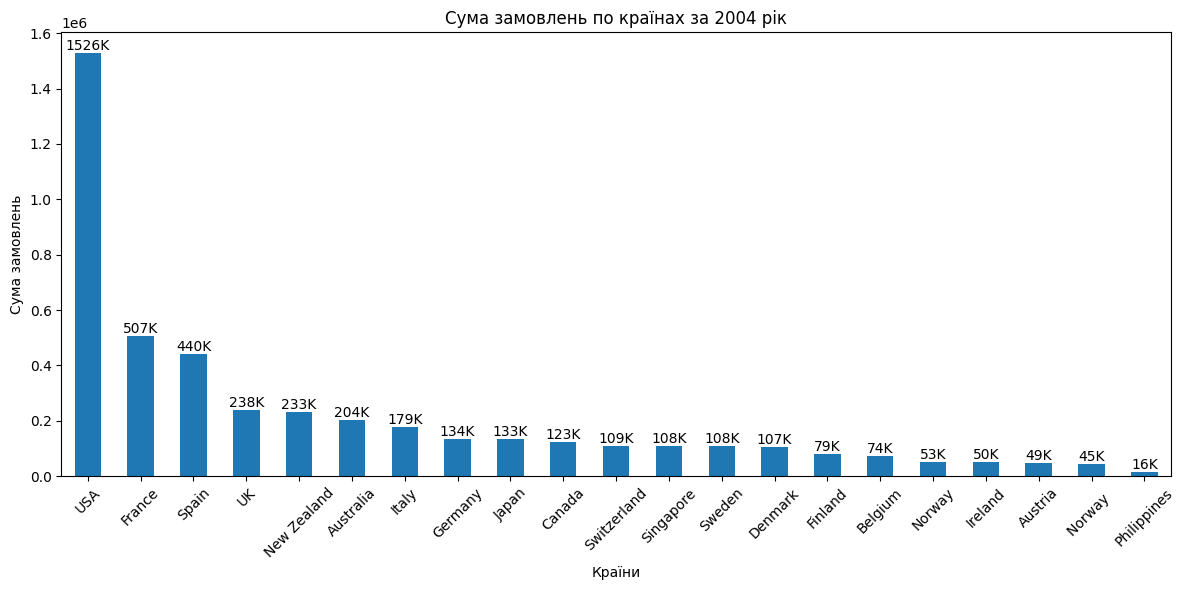

In [6]:
country_orders = df_Ordered.groupby('country')['total_order'].sum().sort_values(ascending=False)
ax = country_orders.plot.bar(country_orders, 
                    figsize=(12, 6),
                    title='Сума замовлень по країнах за 2004 рік',
                    xlabel='Країни',
                    ylabel='Сума замовлень'
)

ax.bar_label(ax.containers[0], fmt='%.0f', labels=[f'{v/1000:.0f}K' for v in country_orders])

plt.xticks(rotation=45)
plt.tight_layout()

Найбільша сума замовлень у 2004 році була у США — 1 526 500 грошових одиниць.

In [7]:
#Країна з найбільшою кількістю замовлень і клієнт, який зробив замовлень на найбільшу суму за 2004 рік.

orders_by_country = df_Ordered['country'].value_counts()
top_country = orders_by_country.idxmax()

df_top_country = df_Ordered[df_Ordered['country'] == top_country]

top_customer = df_top_country.groupby('customerName', as_index=False)['total_order'].sum().sort_values(by = 'total_order', ascending=False)

country_total = df_top_country['total_order'].sum()
top_customer_sum = top_customer['total_order'].iloc[0]
share_pct = top_customer_sum / country_total * 100

print(f"Країна з найбільшою кількістю замовлень: {top_country}")
print(f"Клієнт з найбільшою сумою замовлень: {top_customer['customerName'].iloc[0]}")
print(f"Сума замовлень клієнта: {top_customer_sum:.2f}")
print(f"Частка від суми всіх замовлень у країні: {share_pct:.2f}%")

Країна з найбільшою кількістю замовлень: USA
Клієнт з найбільшою сумою замовлень: Mini Gifts Distributors Ltd.
Сума замовлень клієнта: 231562.53
Частка від суми всіх замовлень у країні: 15.17%



### Завдання 3: Аналітичний запит - Топ продуктів по продажах (6 балів)

В цьому завданні ви отримуєте 1 бал за правильний SQL запит і по 1 балу за кожне завдання з Python.

**Проведіть аналіз прибутковості продуктів** та для цього дістаньте з БД інформацію з наступними полями:
- Назва продукту
- Лінійка продукту (productLine)
- Загальний дохід з цього продукту (сума quantity * priceEach)
- Ранг продукту по доходу (тобто яке місце посідає цей продукт за доходом серед усіх продуктів в нашому магазині)
- Який відсоток від загального доходу компанії складає цей продукт
- Різниця з середнім доходом по лінійці продукту (в %)

Відсортуйте дані за спаданням значень колонки "Який відсоток від загального доходу компанії складає цей продукт".

При створенні SQL запиту вам можуть стати в нагоді:
- **CTE** для розрахунку доходу по кожному продукту
- **Віконні функції** для ранжування та порівняння з середнім

Після отримання даних з БД проведіть обчислення (де треба) з Python та напишіть висновки:
1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?
2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?
4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим відсотком.
5. Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні. Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.

Візуалізацію можна створювати з будь-якою бібліотекою на ваш вибір.

In [8]:
third_query = text("""
    WITH  product_revenue AS (
    	SELECT 
    		p.productCode
    		, p.productName
    		, p.productLine
    		, sum(od.quantityOrdered * od.priceEach) AS product_income
    	FROM products p
    	JOIN orderdetails od ON p.productCode=od.productCode
    	GROUP BY p.productCode, p.productName, p.productLine
    )
    SELECT 
    	productName
    	, productLine
    	, product_income
        , ROUND(AVG(product_income) OVER (PARTITION BY productLine),2) AS avg_income_line
    	, Rank() OVER (ORDER BY product_income DESC) AS income_rank
    	, ROUND(product_income / NULLIF(SUM(product_income) OVER (), 0) * 100.0, 3) AS percent_of_total
        , ROUND(
    		(product_income - AVG(product_income) OVER (PARTITION BY productLine)
    		) 
    		/ NULLIF(AVG(product_income) OVER (PARTITION BY productLine), 0) * 100.0, 2) AS diff_percent
    FROM product_revenue
    ORDER BY percent_of_total DESC
""")

df_product_ordered = pd.read_sql(
    third_query,
    engine,
)

display(df_product_ordered)

,productName,productLine,product_income,avg_income_line,income_rank,percent_of_total,diff_percent
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,104160.07,1,2.882,165.78
1,2001 Ferrari Enzo,Classic Cars,190755.86,104160.07,2,1.986,83.14
2,1952 Alpine Renault 1300,Classic Cars,190017.96,104160.07,3,1.978,82.43
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,86263.55,4,1.777,97.87
4,1968 Ford Mustang,Classic Cars,161531.48,104160.07,5,1.682,55.08
...,...,...,...,...,...,...,...
104,1982 Ducati 996 R,Motorcycles,33268.76,86263.55,105,0.346,-61.43
105,1958 Chevy Corvette Limited Edition,Classic Cars,31627.96,104160.07,106,0.329,-69.64
106,1982 Lamborghini Diablo,Classic Cars,30972.87,104160.07,107,0.322,-70.26
107,1936 Mercedes Benz 500k Roadster,Vintage Cars,29763.39,74898.32,108,0.310,-60.26


#### 1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?

In [9]:
top_product = df_product_ordered['productName'].iloc[0]
top_percent = df_product_ordered['percent_of_total'].iloc[0]

print(f"ТОП1 продукт: '{top_product}', складає {top_percent:.2f}% від загального доходу")

ТОП1 продукт: '1992 Ferrari 360 Spider red', складає 2.88% від загального доходу


#### 2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?

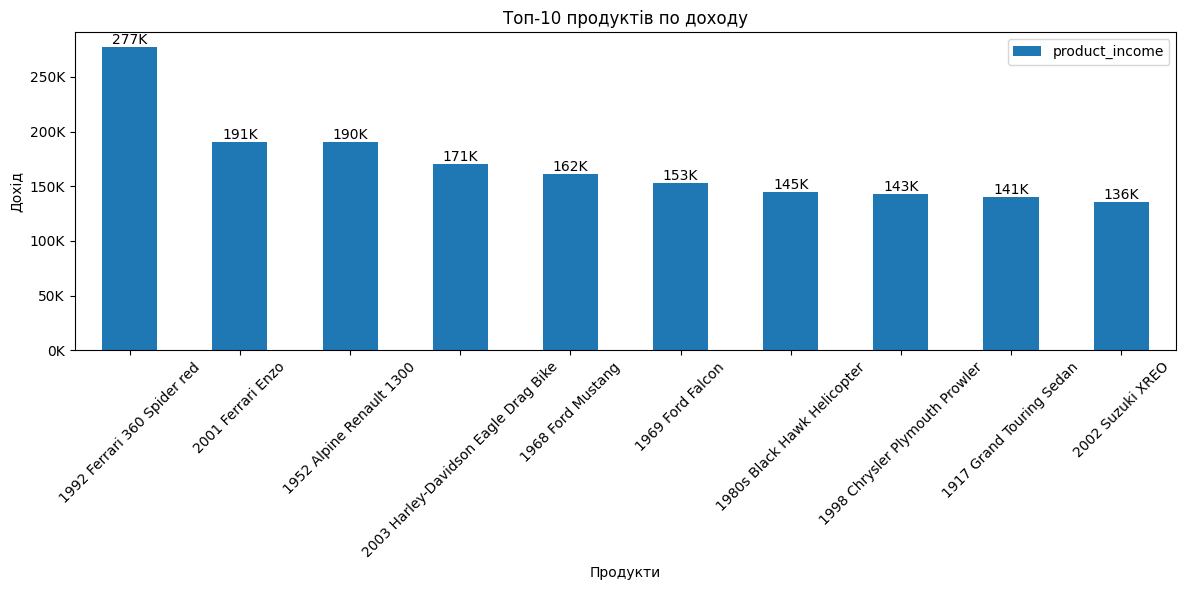

In [10]:
top10_products = df_product_ordered.head(10)
ax = top10_products.plot.bar(x='productName', y='product_income',
                    figsize=(12, 6),
                    title='Топ-10 продуктів по доходу',
                    xlabel='Продукти',
                    ylabel='Дохід'
)

ax.bar_label(ax.containers[0], 
             fmt='%.0f', 
             labels=[f'{v/1000:.0f}K' for v in top10_products['product_income']])

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.xticks(rotation=45)
plt.tight_layout()

In [11]:
top1_name = top10_products['productName'].iloc[0]
top10_name = top10_products['productName'].iloc[9]

top1_income = top10_products['product_income'].iloc[0]
top10_income = top10_products['product_income'].iloc[9]

ratio = top1_income / top10_income

print(f"ТОП1 продукт: {top1_name} — {top1_income:.2f}")
print(f"10-й продукт: {top10_name} — {top10_income:.2f}")
print(f"Дохід ТОП1 продукту більший у {ratio:.2f} рази")

ТОП1 продукт: 1992 Ferrari 360 Spider red — 276839.98
10-й продукт: 2002 Suzuki XREO — 135767.03
Дохід ТОП1 продукту більший у 2.04 рази


#### 3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?

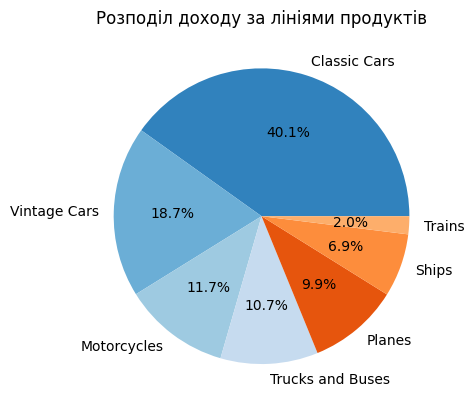

In [12]:
line_income = df_product_ordered.groupby('productLine')['product_income'].sum().sort_values(ascending=False)
line_income.plot.pie(
    autopct='%1.1f%%',
    labels=line_income.index,
    title='Розподіл доходу за лініями продуктів',
    ylabel='',
    colors=plt.cm.tab20c.colors
);

In [13]:
top2_share = line_income.head(2).sum() / line_income.sum() * 100
print(f"ТОП2 лінії продуктів сумарно складають {top2_share:.1f}% від загального доходу")

ТОП2 лінії продуктів сумарно складають 58.8% від загального доходу


**Висновок:** Основну частку доходу формують лінії **Classic Cars** та **Vintage Cars**. Разом вони дають **58.8%** загального доходу компанії.

#### 4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. 
Знайти кількість продуктів сумарне значення "% від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим %.

In [14]:
total_products = len(df_product_ordered)
top80_products_count = (df_product_ordered['percent_of_total'].cumsum() < 80).sum() + 1

print(f"{top80_products_count} продуктів із {total_products} формують 80% загального доходу компанії.")

72 продуктів із 109 формують 80% загального доходу компанії.


#### 5. Які менеджери з продажу приносять найбільший дохід компанії, та чи пов’язаний дохід із кількістю клієнтів, яких вони обслуговують?

In [15]:
fourth_query = text("""
    WITH manager_sales AS (
        SELECT
            e.employeeNumber,
            CONCAT(e.firstName, ' ', e.lastName) AS sales_manager,
            COUNT(DISTINCT c.customerNumber) AS customer_count,
            ROUND(SUM(od.quantityOrdered * od.priceEach), 2) AS total_revenue
        FROM employees e
        JOIN customers c
            ON e.employeeNumber = c.salesRepEmployeeNumber
        JOIN orders o
            ON c.customerNumber = o.customerNumber
        JOIN orderdetails od
            ON o.orderNumber = od.orderNumber
        GROUP BY
            e.employeeNumber,
            CONCAT(e.firstName, ' ', e.lastName)
    )
    SELECT *
    FROM manager_sales
    ORDER BY total_revenue DESC;
    """)

df_emp_income = pd.read_sql(
    fourth_query,
    engine,
)

display(df_emp_income)

,employeeNumber,sales_manager,customer_count,total_revenue
0,1370,Gerard Hernandez,7,1258577.81
1,1165,Leslie Jennings,6,1081530.54
2,1401,Pamela Castillo,10,868220.55
3,1501,Larry Bott,8,732096.79
4,1504,Barry Jones,9,704853.91
5,1323,George Vanauf,8,669377.05
6,1612,Peter Marsh,5,584593.76
7,1337,Loui Bondur,6,569485.75
8,1611,Andy Fixter,5,562582.59
9,1216,Steve Patterson,6,505875.42


Кореляція між кількістю клієнтів та доходом: 0.45


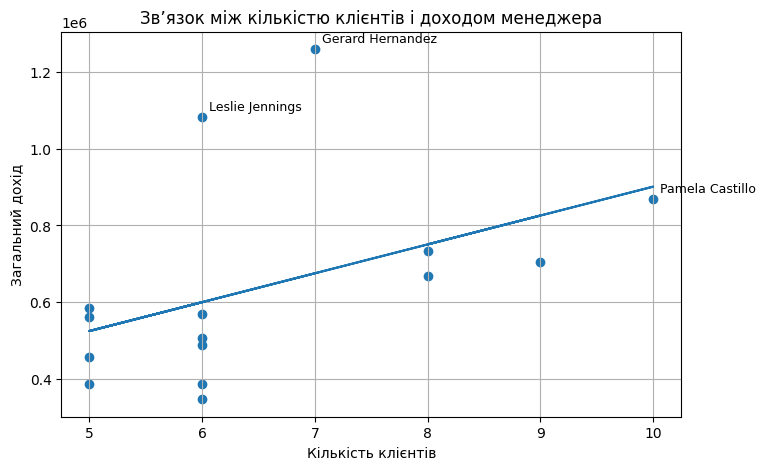

In [16]:
correlation = df_emp_income['customer_count'].corr(df_emp_income['total_revenue'])
print(f'Кореляція між кількістю клієнтів та доходом: {correlation:.2f}')

x = df_emp_income['customer_count']
y = df_emp_income['total_revenue']

plt.figure(figsize=(8, 5))
plt.scatter(x, y)

# лінія тренду
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x))

# підписати топ-3 менеджерів за доходом
top3 = df_emp_income.nlargest(3, 'total_revenue')
for _, row in top3.iterrows():
    plt.annotate(
        row['sales_manager'],
        (row['customer_count'], row['total_revenue']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Кількість клієнтів')
plt.ylabel('Загальний дохід')
plt.title('Зв’язок між кількістю клієнтів і доходом менеджера')
plt.grid(True)
plt.show()

Найбільший дохід приносять **Gerard Hernandez**, **Leslie Jennings** та **Pamela Castillo**.
Розрахована кореляція між кількістю клієнтів і доходом становить 0.45, що свідчить про помірний позитивний зв’язок.
Отже, більша кількість клієнтів частково пов’язана з вищим доходом, але не є єдиним фактором — на результат також впливає обсяг і вартість замовлень.

### ОПЦІОНАЛЬНО. Завдання 4: Аналітичний запит - Динаміка продажів по місяцях (8 балів)

**Проведіть аналіз динаміки продажів по місяцях** та для цього дістаньте з бази інформацію з наступними полями:
- Рік та місяць замовлень
- Кількість замовлень за цей рік-місяць
- Загальний дохід (quantityOrdered * priceEach) за цей рік-місяць
- На який % ми зросли за доходом порівняно з попереднім місяцем
- Накопичувальний дохід до цього місяця за рік
- Ковзне середнє доходу за 3 місяці
- Ранг цього місяця за доходом

Використайте:
- **CTE** для агрегації продажів по місяцях
- **Віконні функції** для розрахунку:
  - Зростання доходу порівняно з попереднім місяцем (LAG)
  - Накопичувальний дохід за рік
  - Ковзне середнє доходу за 3 місяці (AVG OVER)
  - Ранжування місяців за доходом (RANK)

Після отримання даних з БД побудуйте наступні графіки і напишіть коротко, які висновки з них можна зробити.
1. Створіть лінійний графік доходу по місяцях. Чи є тред до зростання в даних?
2. Створіть графік місяць-до-місяця зростання у відсотках.
3. Створіть heatmap сезонності (місяць vs рік)
4. Відобразіть козвне середнє разом з динамікою продажів.
5. Розрахуйте кореляцію між кількістю замовлень та середнім чеком та побудуйте графік розсіювання між цими змінними. Чи є лінійна залежність?

Очікуваний результат кожного графіку - нижче.
В першому графіку я додала лінію тренду аби показати тренд. Вам її додавати не треба.


In [17]:
monthly_sales_query = text("""
WITH monthly_sales AS (
    SELECT
        YEAR(o.orderDate) AS year_order,
        MONTH(o.orderDate) AS month_order,
        COUNT(DISTINCT o.orderNumber) AS order_count,
        SUM(od.quantityOrdered * od.priceEach) AS total_revenue
    FROM orders o
    JOIN orderdetails od
        ON o.orderNumber = od.orderNumber
    GROUP BY
        YEAR(o.orderDate),
        MONTH(o.orderDate)
),
monthly_metrics AS (
    SELECT
        year_order,
        month_order,
        order_count,
        total_revenue,

        LAG(total_revenue) OVER (
            ORDER BY year_order, month_order
        ) AS prev_month_revenue,

        SUM(total_revenue) OVER (
            PARTITION BY year_order
            ORDER BY month_order
        ) AS cumulative_revenue,

        ROUND(AVG(total_revenue) OVER (
            ORDER BY year_order, month_order
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 2) AS moving_avg_3m,

        RANK() OVER (
            PARTITION BY year_order
            ORDER BY total_revenue DESC
        ) AS revenue_rank
    FROM monthly_sales
)
SELECT
    year_order AS `Рік`,
    month_order AS `Місяць`,
    order_count AS `Кількість замовлень`,
    total_revenue AS `Дохід`,
    ROUND(
        (total_revenue - prev_month_revenue) / prev_month_revenue * 100, 2
    ) AS `% зміни до попереднього місяця`,
    cumulative_revenue AS `Накопичувальний дохід за рік`,
    moving_avg_3m AS `Ковзне середнє за 3 місяці`,
    revenue_rank AS `Ранг місяця за доходом`
FROM monthly_metrics
ORDER BY year_order, month_order;
""")

df_monthly = pd.read_sql(monthly_sales_query, engine)
display(df_monthly)

,Рік,Місяць,Кількість замовлень,Дохід,% зміни до попереднього місяця,Накопичувальний дохід за рік,Ковзне середнє за 3 місяці,Ранг місяця за доходом
0,2003,1,5,116692.77,NaN,116692.77,116692.77,12
1,2003,2,3,128403.64,10.04,245096.41,122548.21,11
2,2003,3,6,160517.14,25.01,405613.55,135204.52,9
3,2003,4,7,185848.59,15.78,591462.14,158256.46,6
4,2003,5,6,179435.55,-3.45,770897.69,175267.09,7
5,2003,6,7,150470.77,-16.14,921368.46,171918.30,10
6,2003,7,7,201940.36,34.21,1123308.82,177282.23,5
7,2003,8,5,178257.11,-11.73,1301565.93,176889.41,8
8,2003,9,8,236697.85,32.78,1538263.78,205631.77,4
9,2003,10,18,514336.21,117.30,2052599.99,309763.72,2


In [18]:
df_monthly['Рік-місяць'] = (
    df_monthly['Рік'].astype(str) + '-' +
    df_monthly['Місяць'].astype(str).str.zfill(2)
)
display(df_monthly.head())

,Рік,Місяць,Кількість замовлень,Дохід,% зміни до попереднього місяця,Накопичувальний дохід за рік,Ковзне середнє за 3 місяці,Ранг місяця за доходом,Рік-місяць
0,2003,1,5,116692.77,NaN,116692.77,116692.77,12,2003-01
1,2003,2,3,128403.64,10.04,245096.41,122548.21,11,2003-02
2,2003,3,6,160517.14,25.01,405613.55,135204.52,9,2003-03
3,2003,4,7,185848.59,15.78,591462.14,158256.46,6,2003-04
4,2003,5,6,179435.55,-3.45,770897.69,175267.09,7,2003-05


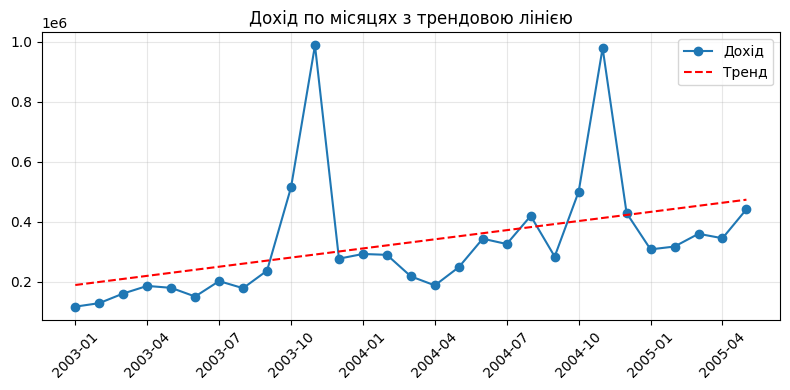

In [19]:
# 1. Лінійний графік доходу з трендом (аби показати, що тренд є)

x = np.arange(len(df_monthly))
y = df_monthly['Дохід']

plt.figure(figsize=(8, 4))  # ширше і нижче

plt.plot(df_monthly['Рік-місяць'], y, marker='o', label='Дохід')

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(df_monthly['Рік-місяць'], p(x), 'r--', label='Тренд')

plt.title('Дохід по місяцях з трендовою лінією')
plt.xticks(df_monthly['Рік-місяць'][::3], rotation=45)  # показувати не всі підписи
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Динаміка доходу по місяцях є нерівномірною, із різкими піками в окремі періоди. Водночас трендова лінія показує загальну тенденцію до зростання доходу з часом.

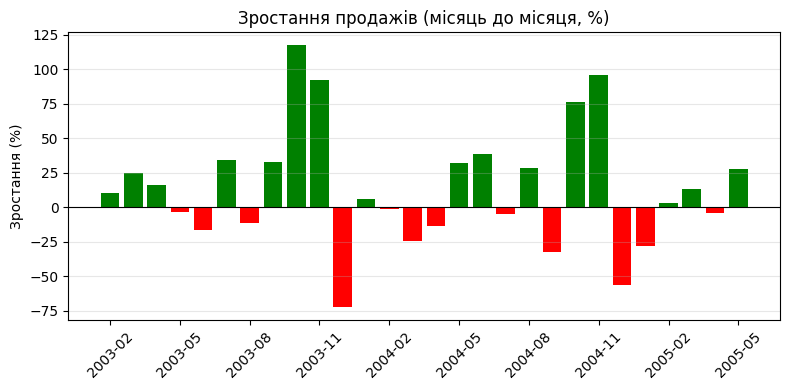

In [20]:
# 2. Місяць-до-місяця зростання

growth = df_monthly.dropna(subset=['% зміни до попереднього місяця']).copy()

colors = ['green' if x >= 0 else 'red' for x in growth['% зміни до попереднього місяця']]

plt.figure(figsize=(8, 4))
plt.bar(growth['Рік-місяць'], growth['% зміни до попереднього місяця'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Зростання продажів (місяць до місяця, %)')
plt.xlabel('')
plt.ylabel('Зростання (%)')
plt.xticks(growth['Рік-місяць'][::3], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Місячне зростання продажів є нестабільним: після періодів суттєвого підйому спостерігаються і значні спади. Це свідчить про коливання попиту та можливу сезонність у продажах.

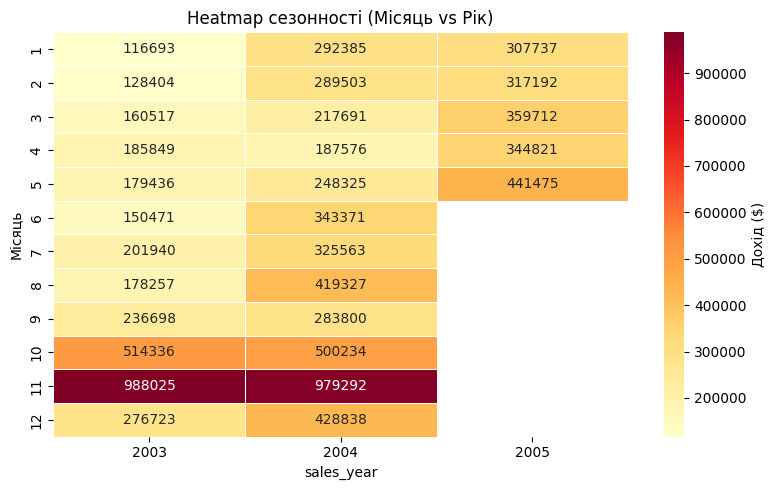

In [21]:
# 3. Heatmap сезонності

pivot_table = df_monthly.pivot(
    index='Місяць',
    columns='Рік',
    values='Дохід'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Дохід ($)'}
)

plt.title('Heatmap сезонності (Місяць vs Рік)')
plt.xlabel('sales_year')
plt.ylabel('Місяць')
plt.tight_layout()
plt.show()

Heatmap показує сезонність продажів: найвищі значення доходу спостерігаються восени, особливо в жовтні–листопаді. Найслабші продажі переважно припадають на початок року та окремі літні місяці.

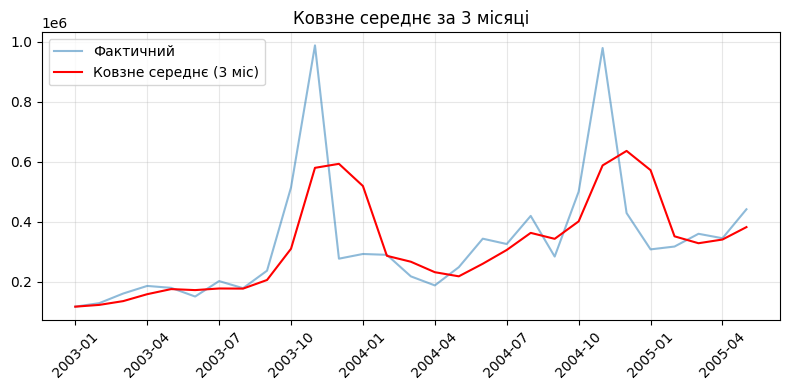

In [22]:
# 4. Ковзне середнє з динімікою доходу

plt.figure(figsize=(8, 4))

plt.plot(df_monthly['Рік-місяць'], df_monthly['Дохід'], label='Фактичний', alpha=0.5)
plt.plot(df_monthly['Рік-місяць'], df_monthly['Ковзне середнє за 3 місяці'], 
         color='red', label='Ковзне середнє (3 міс)')

plt.title('Ковзне середнє за 3 місяці')
plt.xticks(df_monthly['Рік-місяць'][::3], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Ковзне середнє згладжує різкі коливання фактичного доходу та краще показує загальну динаміку продажів. За графіком видно, що після окремих пікових місяців середній рівень доходу також підвищується, але більш плавно.

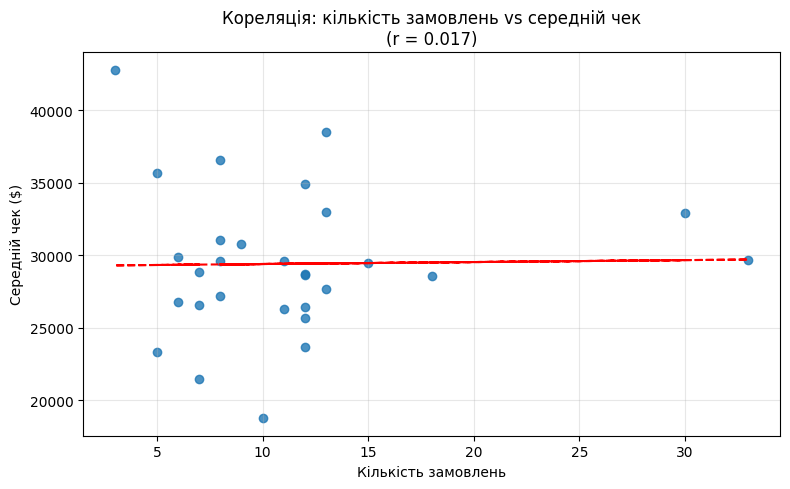

Кореляція між кількістю замовлень і середнім чеком: 0.017


In [23]:
# 5. Кореляція замовлень та середнього чеку

df_corr = df_monthly.copy()
df_corr['Середній чек'] = df_corr['Дохід'] / df_corr['Кількість замовлень']

correlation = df_corr['Кількість замовлень'].corr(df_corr['Середній чек'])

x = df_corr['Кількість замовлень']
y = df_corr['Середній чек']

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.8)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), 'r--')

plt.title(f'Кореляція: кількість замовлень vs середній чек\n(r = {correlation:.3f})')
plt.xlabel('Кількість замовлень')
plt.ylabel('Середній чек ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Кореляція між кількістю замовлень і середнім чеком: {correlation:.3f}')

Попри наявність окремих аутлаєрів, кореляція між кількістю замовлень і середнім чеком дуже слабка (`r = 0.017`), тому лінійна залежність між показниками майже відсутня.

**Time spent — 8 години**

**What I learned:**

- **Інтеграція Python та SQL:** навчилась підключатися до бази даних через `SQLAlchemy engine` і завантажувати результати SQL-запитів у Pandas за допомогою `pd.read_sql()`.
- **Робота із SQL-запитами в Python:** практикувала `SELECT`, `JOIN`, `GROUP BY`, `ORDER BY`, `CTE` та віконні функції (`LAG`, `SUM OVER`, `AVG OVER`, `RANK`) для отримання й підготовки даних до аналізу.
- **Аналітика в Pandas:** після отримання даних із БД виконувала додаткові обчислення в Python — рахувала середній чек, частки, кореляцію, cumulative metrics і готувала таблиці для візуалізації.
- **Візуалізація даних:** будувала графіки в `matplotlib` і `seaborn` — лінійні графіки, bar chart, scatter plot, heatmap, графік ковзного середнього та трендову лінію.
- **Зв’язок SQL + Python на практиці:** побачила повний цикл роботи з даними: підключення до БД → SQL-запит → завантаження в Pandas → аналіз у Python → візуалізація та формулювання висновків.